In [1]:
## Setup path to ClarkeLib
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

In [2]:
from clarkelib import SpaceElevator

## Classic Earth Elevator with exponential tether

In [3]:
tether_material = {'rho':1300, 'ss':50.0, 'ksafe':1.3}

In [4]:
SE = SpaceElevator(
    n_climbers = 7,
    m_climber = 20e3,
    anchor_force = 100e3,
    material = tether_material,
    planet = "Earth",
    taper_func=('exp', 'exp'),
    hcw = 50e6,
    anchor_safe='heavy'
)

In [5]:
SE.stats()
for climber in SE.climbers:
    print()
    print(climber)

----------------------------------
  Planet: Earth
----------------------------------
  R, km                  6371.0
  M, M_Earth             1.0
  T, hr                  23.9348
  h_syn, Mm              35.7927
----------------------------------
  Tether
----------------------------------
  Taper low              exp
  Taper high             exp
  sigma_b, MPa           65000.0
  k_safe                 1.3
  rho, kg/m3             1300.0
  m_tether, tons         1645.21
  s1, mm2                8.2244
  s2, mm2                29.0154
  s3, mm2                28.0223
  k_syn                  3.5279
  k_cw                   3.4072
----------------------------------
  Counterweight
----------------------------------
  h_cw, Mm               50.0
  m_cw, tons             8037.8817
----------------------------------
  Space Elevator
----------------------------------
  n_climbers             7
  m_climber, tons        20.0
  m0, tons               9683.0917
  h0, Mm                 46.667

## Vary counterweight altitude

In [6]:
hcw_start = SE.planet.HSYN * 1.2
hcw_end = SE.planet.HSYN * 2.8
hcw_m0min = SE.varyCWAltitude(hcw_start, hcw_end, 80)

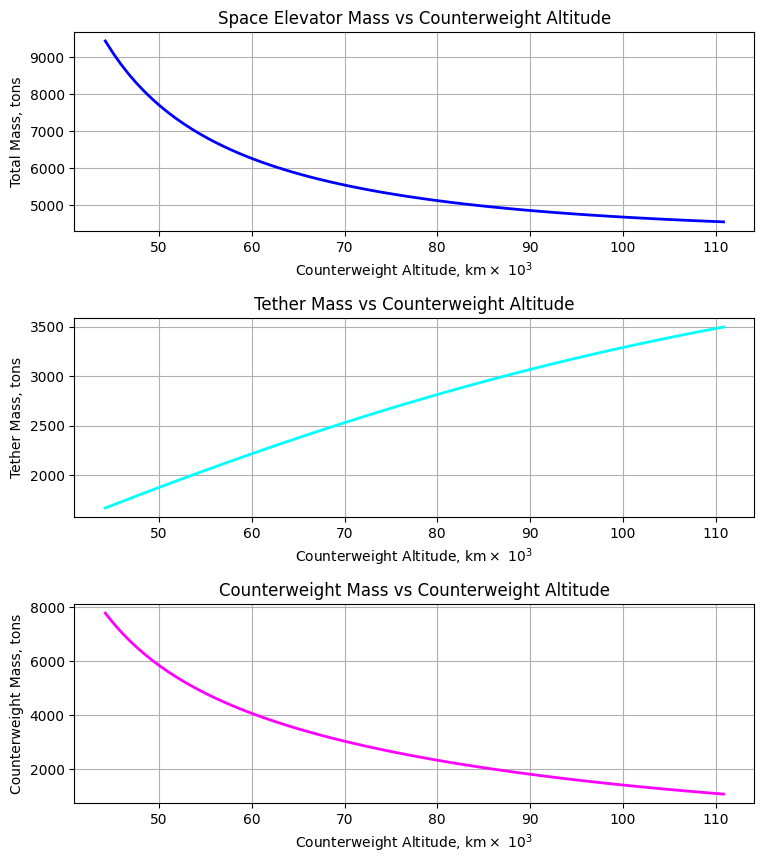

In [7]:
SE.plots.mplplotMvsHcw(figsize = (8,9))

## Reset counterweight altitude and plot diagrams for tether profile and loads

In [8]:
SE.setHcw(50e6+SE.planet.R)

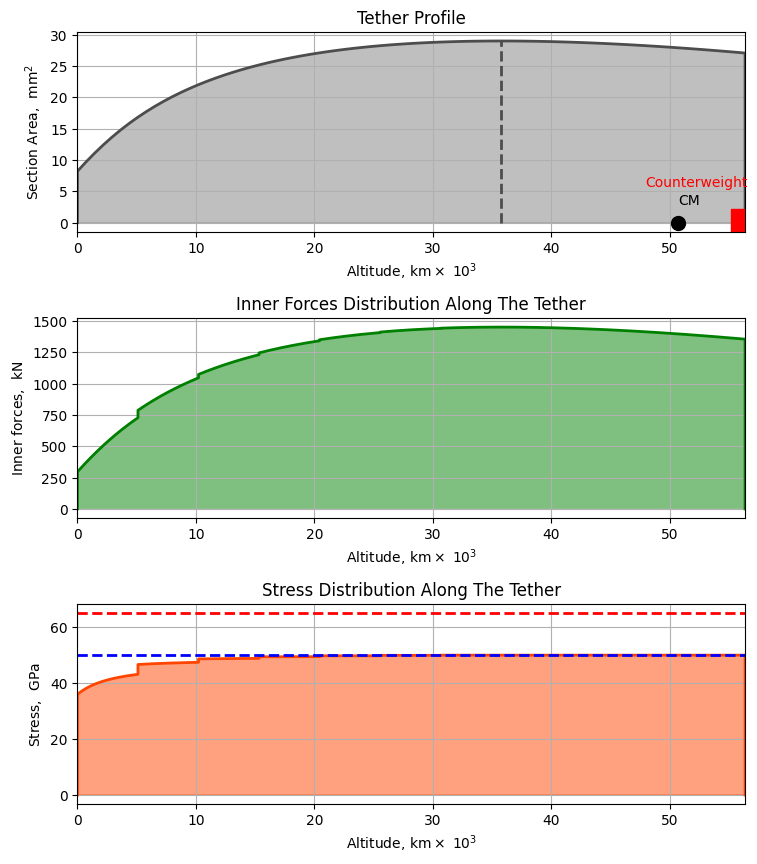

In [9]:
SE.plots.mplplotTetherProfile(climbers=True, figsize = (8,9))

## Earth Elevator with cubic tether tapering

In [10]:
SE = SpaceElevator(
    n_climbers = 7,
    m_climber = 20e3,
    anchor_force = 100e3,
    material = tether_material,
    planet = "Earth",
    taper_func=('cubic', 'exp'),
    hcw = 50e6,
    anchor_safe='light'
)

In [11]:
SE.stats()
for climber in SE.climbers:
    print()
    print(climber)

----------------------------------
  Planet: Earth
----------------------------------
  R, km                  6371.0
  M, M_Earth             1.0
  T, hr                  23.9348
  h_syn, Mm              35.7927
----------------------------------
  Tether
----------------------------------
  Taper low              cubic
  Taper high             exp
  sigma_b, MPa           65000.0
  k_safe                 1.3
  rho, kg/m3             1300.0
  m_tether, tons         1364.6714
  s1, mm2                5.9143
  s2, mm2                24.3831
  s3, mm2                23.5486
  k_syn                  4.1227
  k_cw                   3.9816
----------------------------------
  Counterweight
----------------------------------
  h_cw, Mm               50.0
  m_cw, tons             6754.6481
----------------------------------
  Space Elevator
----------------------------------
  n_climbers             7
  m_climber, tons        20.0
  m0, tons               8119.3195
  h0, Mm                 46

## Vary counterweight altitude

In [12]:
hcw_start = SE.planet.HSYN * 1.2
hcw_end = SE.planet.HSYN * 2.8
hcw_m0min = SE.varyCWAltitude(hcw_start, hcw_end, 80)

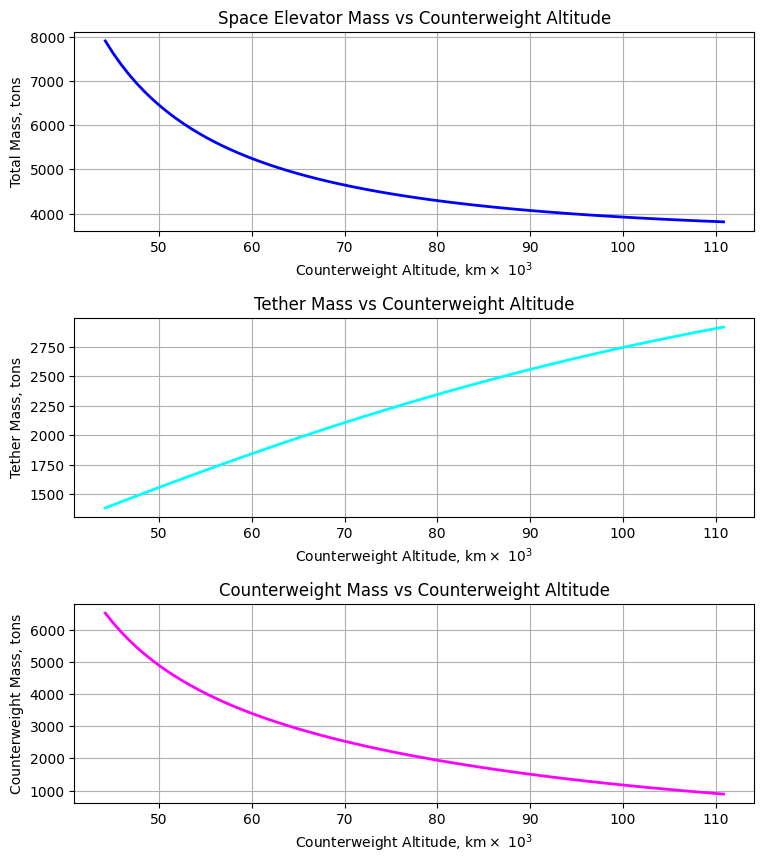

In [13]:
SE.plots.mplplotMvsHcw(figsize = (8,9))

## Reset counterweight altitude and plot diagrams for tether and loads

In [14]:
SE.setHcw(50e6+SE.planet.R)

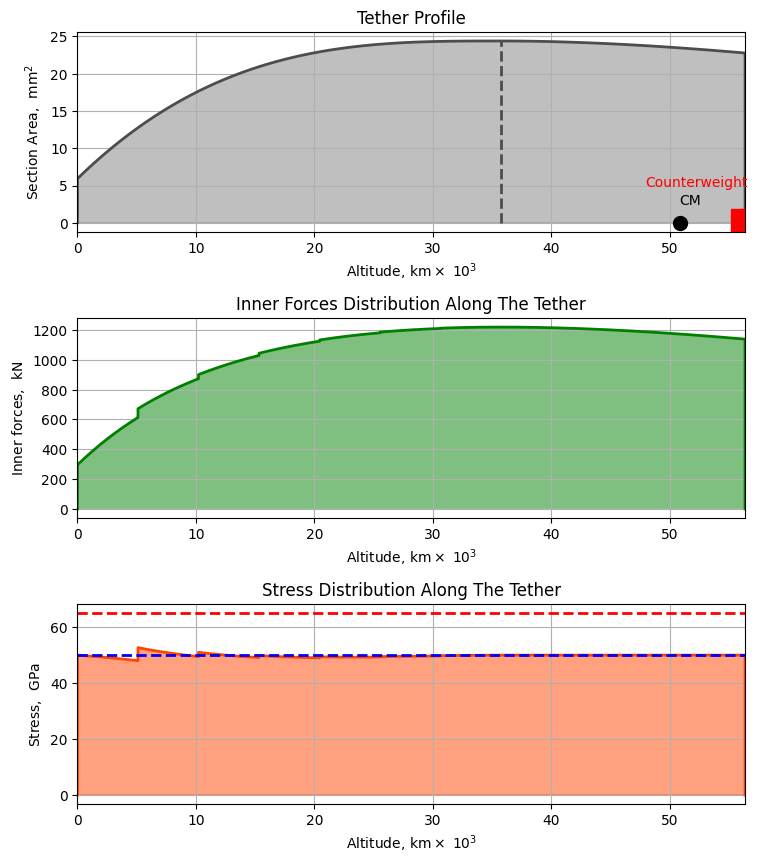

In [15]:
SE.plots.mplplotTetherProfile(climbers=True, figsize = (8,9))